# 03 Neural Models
This notebook reviews saved Text-CNN and BiLSTM-Attention artifacts; it performs no training.

## Why Neural Models Were Added
Neural sequence models test whether learned local patterns and contextual representations improve on sparse TF-IDF features.

## Text-CNN
Text-CNN uses multiple convolution widths to capture local phrase patterns before classification.

## BiLSTM-Attention
The bidirectional LSTM encodes left and right context, while attention combines token states into a tweet representation.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
RESULTS = ROOT / 'outputs' / 'results'

neural = pd.read_csv(RESULTS / 'neural_leaderboard.csv', encoding='utf-8')
neural_metrics = json.loads((RESULTS / 'neural_metrics.json').read_text(encoding='utf-8'))
cnn_history = pd.read_csv(RESULTS / 'neural_text_cnn_training_history.csv', encoding='utf-8')
lstm_history = pd.read_csv(RESULTS / 'neural_bilstm_attention_training_history.csv', encoding='utf-8')
comparison = pd.read_csv(RESULTS / 'model_comparison_leaderboard.csv', encoding='utf-8')

## Training Configuration
Both models used the saved train/validation splits, class weighting, early stopping, maximum sequence length 80, and randomly initialized 300-dimensional embeddings.

## Neural Leaderboard
BiLSTM-Attention has the best neural test Macro-F1, while Text-CNN has higher test accuracy.

In [2]:
neural_test = neural.query("split == 'test'").sort_values('macro_f1', ascending=False)
neural_test[['model_name', 'accuracy', 'macro_precision', 'macro_recall', 'macro_f1', 'weighted_f1']].style.format('{:.4f}', subset=['accuracy', 'macro_precision', 'macro_recall', 'macro_f1', 'weighted_f1'])

,model_name,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
2,bilstm_attention,0.7408,0.4376,0.5256,0.4506,0.7763
3,text_cnn,0.7582,0.4329,0.5084,0.4476,0.7882


## Training Curves
Validation Macro-F1 improved during the saved epochs but remained below the final Linear SVM score.

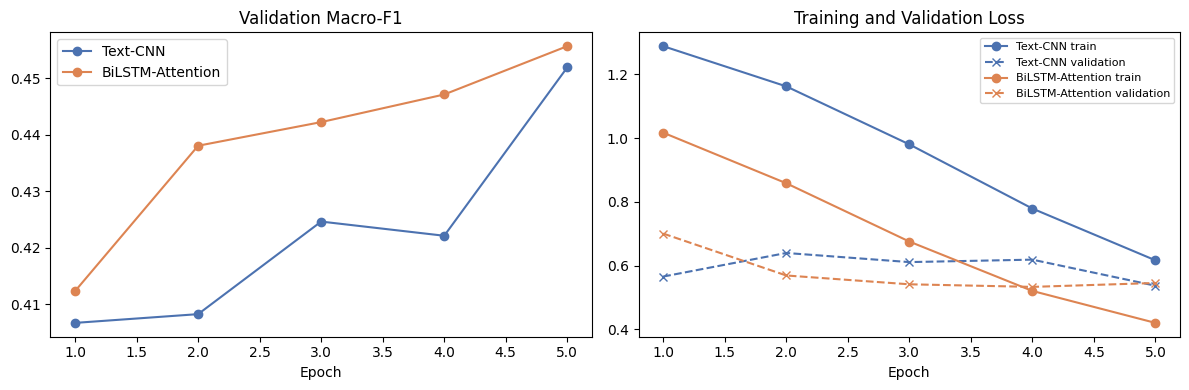

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for history, name, color in [(cnn_history, 'Text-CNN', '#4c72b0'), (lstm_history, 'BiLSTM-Attention', '#dd8452')]:
    axes[0].plot(history['epoch'], history['validation_macro_f1'], marker='o', label=name, color=color)
    axes[1].plot(history['epoch'], history['train_loss'], marker='o', label=f'{name} train', color=color)
    axes[1].plot(history['epoch'], history['validation_loss'], marker='x', linestyle='--', label=f'{name} validation', color=color)
axes[0].set_title('Validation Macro-F1')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[1].set_title('Training and Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## Comparison with Linear SVM
The final leaderboard provides a direct family-level comparison on the same test split.

,model_family,model_name,test_accuracy,test_macro_f1,neutral_f1
0,baseline,linear_svm,0.8531,0.5040,0.1303
2,neural,bilstm_attention,0.7408,0.4506,0.0991
3,neural,text_cnn,0.7582,0.4476,0.0777


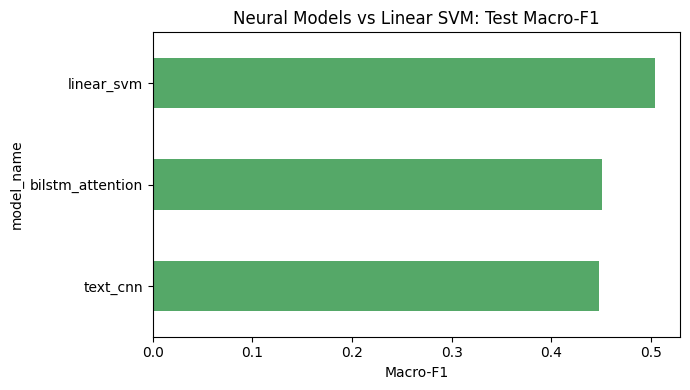

In [4]:
selected = comparison[comparison['model_name'].isin(['linear_svm', 'bilstm_attention', 'text_cnn'])].copy()
display(selected[['model_family', 'model_name', 'test_accuracy', 'test_macro_f1', 'neutral_f1']].style.format('{:.4f}', subset=['test_accuracy', 'test_macro_f1', 'neutral_f1']))
selected.set_index('model_name')['test_macro_f1'].sort_values().plot(kind='barh', figsize=(7, 4), color='#55a868')
plt.title('Neural Models vs Linear SVM: Test Macro-F1')
plt.xlabel('Macro-F1')
plt.tight_layout()
plt.show()

## Why Neural Models Did Not Win
Randomly initialized embeddings had to learn Urdu lexical structure from the project data alone. Severe imbalance, weak-label noise, and limited minority examples further constrained representation learning.

## Key Takeaways
BiLSTM-Attention reached 0.4506 test Macro-F1 and Text-CNN reached 0.4476. Both are meaningful comparisons, but neither exceeded Linear SVM's 0.5040.